# MAGIC Gamma Telescope – Real-Data-Analyse mit DL3

## Vom simulierten Klassifikationsproblem zur statistischen Quellendetektion

Dieses Notebook ergänzt den Machine-Learning-Teil des Portfolio-Projekts um eine Analyse **realer MAGIC-Beobachtungsdaten** im DL3-Format.

Der wichtigste Unterschied zum UCI-Datensatz:

- **UCI:** simulierte Ereignisse mit bekannten Gamma-/Hadron-Labels → überwachtes Lernen.
- **MAGIC DL3:** reale rekonstruierte Ereignisse ohne Ereignis-für-Ereignis-Ground-Truth → das Gamma-Signal wird **statistisch** aus ON- und OFF-Regionen bestimmt.

### Fragestellungen

1. Lässt sich die Crab-Nebel-Quelle in einer realen MAGIC-Beobachtung statistisch nachweisen?
2. Wie verändern sich sichere Energieschwelle und beobachtete Gamma-Excess-Rate bei zunehmendem **Night-Sky Background (NSB)**?
3. Wie verändert sich die beobachtete Excess-Rate, wenn die Quelle weiter vom Kamerazentrum entfernt liegt (**Camera Offset**)?

> **Lesetipp:** Die Markdown-Zellen erklären jeweils zuerst die Physik. Die anschließenden Code-Zellen setzen genau diesen Schritt technisch um.

## 1. Physikalischer Hintergrund

### 1.1 Was misst MAGIC eigentlich?

Gammastrahlung besteht aus sehr energiereichen **Photonen**. Die MAGIC-Teleskope registrieren diese Photonen nicht direkt.

Vereinfacht läuft die Messung so ab:

1. Ein hochenergetisches Gamma-Photon trifft auf die Erdatmosphäre.
2. Es erzeugt eine Kaskade sekundärer Teilchen – einen **Luftschauer**.
3. Geladene Teilchen im Schauer erzeugen einen sehr kurzen Blitz aus **Cherenkov-Licht**.
4. Die MAGIC-Kameras erfassen dieses Licht.
5. Aus dem Kamerabild werden unter anderem **Energie** und **Ankunftsrichtung** des ursprünglichen Ereignisses rekonstruiert.

Das Hauptproblem: Auch kosmische Strahlung aus Protonen und anderen Hadronen erzeugt Luftschauer. Nach der Rekonstruktion und Gamma-/Hadron-Selektion bleibt deshalb immer noch ein erheblicher **Untergrund** übrig.

### 1.2 Warum der Crab-Nebel?

Der Crab-Nebel ist eine helle und gut untersuchte Gammaquelle. Er wird in der bodengebundenen Gammaastronomie häufig als Referenzquelle verwendet. Für dieses Portfolio-Projekt ist er deshalb besonders geeignet: Wenn die Analyse funktioniert, sollte aus der Richtung des Crab-Nebels ein deutlicher statistischer Überschuss gegenüber dem Untergrund sichtbar werden.

### 1.3 Die wichtigsten Begriffe

| Begriff | Bedeutung in diesem Notebook |
|---|---|
| **DL3 event** | Rekonstruiertes Ereignis mit Zeit, Richtung und Energie. Es ist **nicht** automatisch ein echtes Gamma-Ereignis. |
| **ON region** | Himmelsbereich um die bekannte Position des Crab-Nebels. Dort erwarten wir Signal **plus** Untergrund. |
| **OFF region** | Vergleichsregion ohne Quelle. Sie dient zur Abschätzung des Untergrunds unter möglichst ähnlichen Beobachtungsbedingungen. |
| **Wobble observation** | Das Teleskop zeigt absichtlich etwas neben die Quelle. Dadurch können ON- und mehrere OFF-Regionen gleichzeitig im gleichen Kamerafeld liegen. |
| **RAD_MAX** | Energieabhängiger maximaler Winkelabstand zur Quelle, innerhalb dessen Ereignisse zur ON-Region gezählt werden. |
| **alpha** | Normierungsfaktor zwischen OFF- und ON-Akzeptanz. Bei drei vergleichbaren OFF-Regionen ist `alpha` typischerweise ungefähr `1/3`. |
| **Background** | Erwartete Untergrundereignisse in der ON-Region: `alpha × N_OFF`. |
| **Excess** | Statistisch der Quelle zugeschriebener Überschuss: `N_ON - alpha × N_OFF`. |
| **Significance** | Stärke des statistischen Quellennachweises, hier als `sqrt(TS)` näherungsweise in Sigma. **Keine ML-Metrik.** |
| **IRF** | Instrument Response Function: Beschreibung, wie das Teleskop auf Ereignisse verschiedener Energie/Geometrie reagiert. |
| **Safe energy threshold** | Untere Energiegrenze, ab der die Instrumentantwort für die jeweilige Beobachtung als zuverlässig gilt. |
| **NSB** | Night-Sky Background: optischer Nachthimmel-Untergrund; Mondlicht erhöht ihn. |
| **Camera offset** | Winkelabstand zwischen Quelle und Kamerazentrum / Pointing-Richtung. |

Die zentrale ON/OFF-Rechnung lautet:

\[
N_{\mathrm{background}} = \alpha N_{\mathrm{OFF}}
\]

\[
N_{\mathrm{excess}} = N_{\mathrm{ON}} - \alpha N_{\mathrm{OFF}}
\]

Wichtig: Ein **Excess von 277** bedeutet nicht, dass 277 einzelne Ereignisse sicher als Gamma-Photonen identifiziert wurden. Es ist ein statistischer Überschuss über den erwarteten Untergrund.

## 2. Setup und Pfade

Das vollständige MAGIC-PDR1-Dataset ist zu groß für dieses Git-Repository und wird deshalb **außerhalb des Repositories** gespeichert.

Für reproduzierbare Ausführung wird der Pfad über die Umgebungsvariable `MAGIC_DL3_DATA_DIR` gesetzt. So landet kein persönlicher Windows-Pfad im öffentlichen Notebook.

Beispiel für eine PowerShell-Sitzung:

```powershell
$env:MAGIC_DL3_DATA_DIR = "C:\path\to\magic_dl3_pdr1"
```

Der einzelne Pilot-Run liegt dagegen im Repository unter `data/dl3/raw/` und kann unabhängig vom vollständigen Dataset untersucht werden.

Die Analyse wurde mit **Gammapy 2.1** und **regions 0.11** validiert.

> **Hinweis zur bereinigten Datei:** Die relevanten Ergebnisplots aus dem bereits validierten Lauf wurden beibehalten, damit das Notebook auch auf GitHub vollständig lesbar ist. Für eine Reproduktion bitte nach dem Setzen von `MAGIC_DL3_DATA_DIR` einmal **Run All** ausführen.

In [1]:
import io
import os
from contextlib import redirect_stderr, redirect_stdout
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table

from regions import PointSkyRegion

from gammapy.data import Observation
from gammapy.datasets import Datasets, SpectrumDataset
from gammapy.maps import MapAxis, RegionGeom
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    WobbleRegionsFinder,
)


def find_project_root(start=None):
    """Find repository root by searching upwards for pyproject.toml."""
    path = Path.cwd() if start is None else Path(start)

    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError("Project root could not be found.")


PROJECT_ROOT = find_project_root()

DATA_DL3_RAW = PROJECT_ROOT / "data" / "dl3" / "raw"
RESULTS_DL3_DIR = PROJECT_ROOT / "results" / "dl3"
RESULTS_DL3_FIGURES = RESULTS_DL3_DIR / "figures"
RESULTS_DL3_TABLES = RESULTS_DL3_DIR / "tables"

RESULTS_DL3_FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS_DL3_TABLES.mkdir(parents=True, exist_ok=True)

PILOT_FILE = (
    DATA_DL3_RAW
    / "20131113_05030908_DL3_CrabNebula-W0.40+215.fits"
)

external_root_env = os.getenv("MAGIC_DL3_DATA_DIR")
DL3_EXTERNAL_ROOT = (
    Path(external_root_env).expanduser()
    if external_root_env
    else None
)

print("Project root:", PROJECT_ROOT)
print("Pilot file exists:", PILOT_FILE.exists())
print(
    "Full DL3 dataset:",
    DL3_EXTERNAL_ROOT if DL3_EXTERNAL_ROOT else "not configured"
)

## 3. Ein realer DL3-Run: Welche Daten liegen überhaupt vor?

Bevor wir eine astronomische Statistik berechnen, schauen wir uns einen einzelnen Run an.

Die entscheidende Beobachtung für die Verbindung zum ML-Projekt ist:

- In `EVENTS` stehen nur rekonstruierte Ereignisgrößen wie **RA, DEC, ENERGY und TIME**.
- Die Datei enthält zusätzlich die Instrumentantwort, z. B. `RAD_MAX`, `EFFECTIVE AREA` und `ENERGY DISPERSION`.
- Es gibt **keine Spalte `gamma/hadron`** und auch nicht die zehn UCI-Hillas-Features.

Deshalb kann das UCI-Modell nicht einfach auf diese DL3-Datei angewendet werden.

In [2]:
with fits.open(PILOT_FILE) as hdul:
    hdu_overview = pd.DataFrame(
        {
            "HDU": [hdu.name for hdu in hdul],
            "rows / shape": [
                getattr(getattr(hdu, "data", None), "shape", None)
                for hdu in hdul
            ],
        }
    )

    events = Table(hdul["EVENTS"].data)

display(hdu_overview)
display(events[:10])

### Interpretation der DL3-Struktur

`EVENTS` enthält die **rekonstruierten Kandidatenereignisse**. Ein solches Ereignis ist noch kein sicher identifiziertes Gamma-Photon.

Die übrigen HDUs beschreiben die Instrumentantwort:

- **RAD_MAX:** zulässiger Winkelabstand zur Quelle in Abhängigkeit von der Energie.
- **EFFECTIVE AREA:** effektive Sammelfläche des Instruments.
- **ENERGY DISPERSION:** Zusammenhang zwischen wahrer und rekonstruierter Energie.

Damit ist DL3 bereits eine wesentlich höhere Analyseebene als der UCI-Datensatz: Die ursprünglichen Kamerabilder bzw. Hillas-Parameter sind hier nicht mehr vorhanden.

## 4. ON/OFF-Methode verständlich gemacht

MAGIC beobachtet den Crab-Nebel typischerweise im **Wobble-Modus**: Die Pointing-Richtung liegt etwas neben der Quelle.

Das hat einen großen Vorteil:

- Die **ON-Region** liegt auf dem Crab-Nebel.
- Mehrere **OFF-Regionen** liegen in vergleichbarem Abstand vom Kamerazentrum.
- Aus den OFF-Regionen lässt sich der verbleibende kosmische Untergrund abschätzen.

Die folgende Grafik ist **schematisch**. Die reale Analyse verwendet die in den DL3-Dateien hinterlegte Beobachtungsgeometrie und das energieabhängige `RAD_MAX`.

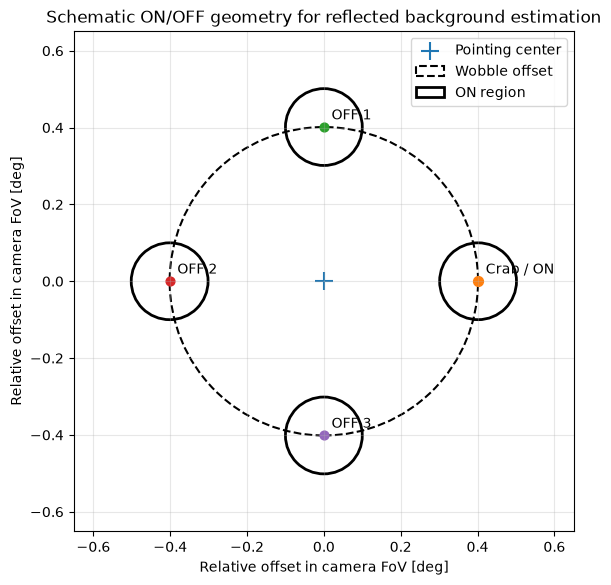

In [3]:
from matplotlib.patches import Circle

# Representative geometry for explanation only.
wobble_offset_deg = 0.4014
on_radius_deg = 0.10
n_off = 3

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(0, 0, marker="+", s=150, label="Pointing center")

wobble_circle = Circle(
    (0, 0),
    wobble_offset_deg,
    fill=False,
    linestyle="--",
    linewidth=1.5,
    label="Wobble offset",
)
ax.add_patch(wobble_circle)

on_x, on_y = wobble_offset_deg, 0.0
ax.add_patch(
    Circle(
        (on_x, on_y),
        on_radius_deg,
        fill=False,
        linewidth=2,
        label="ON region",
    )
)
ax.scatter(on_x, on_y, s=50)
ax.text(on_x + 0.02, on_y + 0.02, "Crab / ON", fontsize=10)

for i, angle_deg in enumerate([90, 180, 270], start=1):
    angle_rad = np.deg2rad(angle_deg)
    x = wobble_offset_deg * np.cos(angle_rad)
    y = wobble_offset_deg * np.sin(angle_rad)

    ax.add_patch(
        Circle(
            (x, y),
            on_radius_deg,
            fill=False,
            linewidth=2,
        )
    )
    ax.scatter(x, y, s=40)
    ax.text(x + 0.02, y + 0.02, f"OFF {i}", fontsize=10)

ax.set_aspect("equal")
ax.set_xlabel("Relative offset in camera FoV [deg]")
ax.set_ylabel("Relative offset in camera FoV [deg]")
ax.set_title("Schematic ON/OFF geometry for reflected background estimation")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

lim = wobble_offset_deg + on_radius_deg + 0.15
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

plt.tight_layout()
plt.savefig(
    RESULTS_DL3_FIGURES / "dl3_on_off_geometry_schematic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 5. Gammapy-Analyse-Pipeline

Die Pipeline ist für jeden Run gleich:

1. DL3-Beobachtung einlesen.
2. Ereignisse in die energieabhängige ON-Region füllen.
3. Instrumentantwort (`exposure`, `edisp`) übernehmen.
4. Reflektierte OFF-Regionen für die Background-Schätzung bestimmen.
5. `SafeMaskMaker(methods=["aeff-default"])` anwenden. Dadurch werden die in den IRF-Metadaten empfohlenen sicheren Energiegrenzen berücksichtigt.
6. ON, OFF, Background, Excess und Signifikanz berechnen.

Für die Multi-Offset-Daten benötigen die kleinsten Offsets weniger OFF-Regionen, weil sich die Regionen sonst geometrisch überlappen:

| Camera offset | verwendete OFF-Regionen | typisches alpha |
|---:|---:|---:|
| 0.20° | 1 | 1.0 |
| 0.35° | 2 | 0.5 |
| ≥ 0.40° | 3 | 1/3 |

Diese Wahl wurde vor der Batch-Auswertung an repräsentativen Runs geprüft.

In [4]:
# Target position: Crab Nebula
target_position = SkyCoord(
    ra=83.63333,
    dec=22.01444,
    unit="deg",
    frame="icrs",
)

# PointSkyRegion tells Gammapy to use the energy-dependent RAD_MAX
# provided by the MAGIC DL3 files.
on_region = PointSkyRegion(target_position)

# Reconstructed energy axis used for the ON/OFF spectrum.
energy_axis = MapAxis.from_energy_bounds(
    50,
    1e5,
    nbin=5,
    per_decade=True,
    unit="GeV",
    name="energy",
)

# True-energy axis needed for the instrument response.
energy_axis_true = MapAxis.from_energy_bounds(
    10,
    1e5,
    nbin=10,
    per_decade=True,
    unit="GeV",
    name="energy_true",
)

geom = RegionGeom.create(
    region=on_region,
    axes=[energy_axis],
)

dataset_empty = SpectrumDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
)

dataset_maker = SpectrumDatasetMaker(
    containment_correction=False,
    selection=["counts", "exposure", "edisp"],
)

safe_mask_maker = SafeMaskMaker(
    methods=["aeff-default"]
)

In [5]:
def lowest_safe_energy(dataset):
    """Return the lower edge of the first safe reconstructed-energy bin."""
    safe_mask = np.squeeze(dataset.mask_safe.data).astype(bool)
    energy_edges = (
        dataset.counts.geom.axes["energy"]
        .edges
        .to_value("TeV")
    )

    safe_indices = np.flatnonzero(safe_mask)

    if len(safe_indices) == 0:
        return np.nan

    return float(energy_edges[safe_indices[0]])


def process_magic_run(file_path, n_off_regions=3):
    """
    Reduce one MAGIC DL3 observation to an ON/OFF spectrum.

    Returns
    -------
    dataset_on_off
        Gammapy SpectrumDatasetOnOff.
    summary
        Compact dictionary with the quantities used in this notebook.
    """
    observation = Observation.read(file_path)

    # Fill ON counts and attach exposure / energy dispersion.
    dataset = dataset_maker.run(
        dataset_empty.copy(name=str(observation.obs_id)),
        observation,
    )

    # Build reflected OFF regions with a geometry suitable for this run.
    region_finder = WobbleRegionsFinder(
        n_off_regions=n_off_regions
    )
    background_maker = ReflectedRegionsBackgroundMaker(
        region_finder=region_finder
    )

    dataset_on_off = background_maker.run(
        dataset,
        observation,
    )

    # Apply the recommended safe-energy range from the IRF metadata.
    dataset_on_off = safe_mask_maker.run(
        dataset_on_off,
        observation,
    )

    info = dataset_on_off.info_dict()

    summary = {
        "obs_id": int(observation.obs_id),
        "file": str(file_path),
        "livetime_min": float(
            info["livetime"].to_value("min")
        ),
        "counts_on": int(info["counts"]),
        "counts_off": int(info["counts_off"]),
        "alpha": float(info["alpha"]),
        "background": float(info["background"]),
        "excess": float(info["excess"]),
        "significance": float(info["sqrt_ts"]),
        "safe_energy_min_TeV": lowest_safe_energy(
            dataset_on_off
        ),
    }

    return dataset_on_off, summary, observation


def get_n_off_regions(file_path):
    """Choose a non-overlapping OFF geometry for the multi-offset sample."""
    offset_name = file_path.parent.name

    return {
        "offset_0.20": 1,
        "offset_0.35": 2,
    }.get(offset_name, 3)

## 6. Pilot-Run: funktioniert die ON/OFF-Analyse?

Zuerst analysieren wir nur den einzelnen Run im Repository. So ist die Logik nachvollziehbar, bevor hunderte Dateien verarbeitet werden.

In [6]:
pilot_dataset, pilot_summary, pilot_observation = process_magic_run(
    PILOT_FILE,
    n_off_regions=3,
)

pilot_result = pd.DataFrame(
    [
        {
            "OBS_ID": pilot_summary["obs_id"],
            "Livetime [min]": pilot_summary["livetime_min"],
            "ON": pilot_summary["counts_on"],
            "OFF": pilot_summary["counts_off"],
            "alpha": pilot_summary["alpha"],
            "Background": pilot_summary["background"],
            "Excess": pilot_summary["excess"],
            "Significance [sigma]": pilot_summary["significance"],
            "Safe Emin [TeV]": pilot_summary["safe_energy_min_TeV"],
        }
    ]
)

pilot_result.round(3)

 OBS_ID  Livetime [min]  ON  OFF  alpha  Background  Excess  Significance [sigma]  Safe Emin [TeV]
5030908          19.586 426  446  0.333     148.667 277.333                15.144            0.078

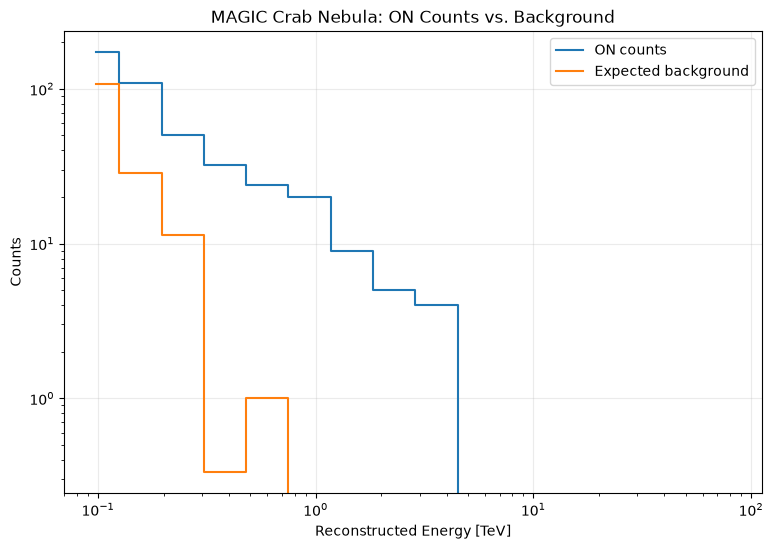

In [7]:
energy_axis_plot = pilot_dataset.counts.geom.axes["energy"]
e_min = energy_axis_plot.edges[:-1].to_value("TeV")
e_max = energy_axis_plot.edges[1:].to_value("TeV")
e_center = np.sqrt(e_min * e_max)

counts_on = np.squeeze(pilot_dataset.counts.data)
counts_off = np.squeeze(pilot_dataset.counts_off.data)
alpha = np.squeeze(pilot_dataset.alpha.data)

background = alpha * counts_off
excess = counts_on - background
safe_mask = np.squeeze(pilot_dataset.mask_safe.data).astype(bool)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.step(e_center, counts_on, where="mid", label="ON counts")
ax.step(
    e_center,
    background,
    where="mid",
    label="Estimated background",
)
ax.step(e_center, excess, where="mid", label="Excess")

ax.scatter(
    e_center[safe_mask],
    excess[safe_mask],
    label="Excess (safe bins)",
)

ax.set_xscale("log")
ax.set_xlabel("Reconstructed energy [TeV]")
ax.set_ylabel("Counts per bin")
ax.set_title("Crab Nebula: ON counts, background and excess")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    RESULTS_DL3_FIGURES / "dl3_on_background_excess.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Pilot-Ergebnis

Für den Pilot-Run ergibt die bestehende Analyse:

- Livetime: **19.59 min**
- ON-Ereignisse im sicheren Energiebereich: **426**
- OFF-Ereignisse: **446**
- `alpha = 1/3`
- erwarteter Background in ON: **148.7**
- Excess: **277.3**
- Signifikanz: **15.14 σ**

Die Rechnung für den Überschuss ist direkt nachvollziehbar:

\[
426 - \frac{1}{3}\cdot 446 \approx 277.3
\]

**Interpretation:** Aus der Richtung des Crab-Nebels kommen deutlich mehr Ereignisse, als allein durch den mit OFF-Regionen geschätzten Untergrund erwartet werden. Das ist ein klarer statistischer Quellennachweis.

**Wichtig:** Die 277.3 Excess-Ereignisse sind eine statistische Größe – keine 277 einzeln gelabelten Gamma-Photonen. Genau hier unterscheidet sich die reale DL3-Analyse grundlegend vom überwachten UCI-Klassifikationsproblem.

## 7. Vollständiges PDR1-Dataset und zwei getrennte Analysezweige

Das lokale PDR1-Dataset enthält in dieser Auswertung **269 FITS-Dateien**:

- `dark/single_offset`: 98
- `dark/multi_offset`: 71
- `moon/NSB_1-2`: 76
- `moon/NSB_2-3`: 3
- `moon/NSB_3-5`: 11
- `moon/NSB_5-8`: 10

Zwischen `dark/single_offset` und `dark/multi_offset` gibt es **26 gemeinsame OBS_IDs**. Laut Dataset-README sind die 0.4°-Multi-Offset-Beobachtungen eine Teilmenge des Single-Offset-Samples, jedoch mit IRFs aus einer anderen Monte-Carlo-Produktion.

Deshalb werden die beiden Dark-Varianten **nicht gemeinsam gestackt**.

Wir verwenden zwei getrennte Analysezweige:

- **Analyse A – NSB / Mondlicht:** 98 `dark/single_offset` + 100 Moon-Runs = **198 Runs**
- **Analyse B – Camera offset:** 71 `dark/multi_offset` Runs

In [8]:
if DL3_EXTERNAL_ROOT is None:
    raise RuntimeError(
        "Set the environment variable MAGIC_DL3_DATA_DIR "
        "to the local MAGIC PDR1 dataset before running the batch analysis."
    )

# Accept either the outer download directory or the repository directory itself.
crab_candidates = [
    DL3_EXTERNAL_ROOT
    / "magic_dl3_pdr1-main"
    / "data"
    / "CrabNebula",
    DL3_EXTERNAL_ROOT
    / "data"
    / "CrabNebula",
]

CRAB_DATA_ROOT = next(
    (path for path in crab_candidates if path.exists()),
    None,
)

if CRAB_DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/CrabNebula below MAGIC_DL3_DATA_DIR."
    )

analysis_groups = {
    "dark_single_offset":
        CRAB_DATA_ROOT / "dark" / "single_offset",
    "dark_multi_offset":
        CRAB_DATA_ROOT / "dark" / "multi_offset",
    "moon_NSB_1-2":
        CRAB_DATA_ROOT / "moon" / "NSB_1-2",
    "moon_NSB_2-3":
        CRAB_DATA_ROOT / "moon" / "NSB_2-3",
    "moon_NSB_3-5":
        CRAB_DATA_ROOT / "moon" / "NSB_3-5",
    "moon_NSB_5-8":
        CRAB_DATA_ROOT / "moon" / "NSB_5-8",
}

files_by_group = {
    group: sorted(
        directory.rglob("*_DL3_CrabNebula-*.fits")
    )
    for group, directory in analysis_groups.items()
}

for group, files in files_by_group.items():
    print(f"{group:25s}: {len(files):3d} files")

dark_single_offset       :  98 files
dark_multi_offset        :  71 files
moon_NSB_1-2             :  76 files
moon_NSB_2-3             :   3 files
moon_NSB_3-5             :  11 files
moon_NSB_5-8             :  10 files


# Analyse A – Einfluss des Night-Sky Backgrounds

## 8. Warum sollte Mondlicht einen Unterschied machen?

Die MAGIC-Kamera misst extrem kurze und schwache Cherenkov-Lichtblitze. Hellerer Nachthimmel – insbesondere Mondlicht – erzeugt zusätzliches optisches Licht in der Kamera.

Für die Analyse bedeutet das:

- schwache, niedrigenergetische Schauer werden schwieriger zuverlässig zu rekonstruieren,
- die sichere untere Energiegrenze kann steigen,
- die Zahl nutzbarer Quellereignisse pro Beobachtungszeit kann sinken.

Die Gruppen `NSB_1-2` bis `NSB_5-8` repräsentieren zunehmend hellere Nachthimmelbedingungen.

Wir vergleichen bewusst **Excess pro Stunde** statt nur den Gesamt-Excess, weil die Gruppen sehr unterschiedliche Beobachtungszeiten enthalten.

In [9]:
single_moon_groups = [
    "dark_single_offset",
    "moon_NSB_1-2",
    "moon_NSB_2-3",
    "moon_NSB_3-5",
    "moon_NSB_5-8",
]

single_moon_summaries = []
single_moon_datasets = []
single_moon_failures = []

for group in single_moon_groups:
    for file_path in files_by_group[group]:
        try:
            # Suppress repetitive library warnings in the portfolio output.
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                dataset, summary, _ = process_magic_run(
                    file_path,
                    n_off_regions=3,
                )

            summary["group"] = group
            summary["filename"] = file_path.name

            single_moon_summaries.append(summary)
            single_moon_datasets.append(dataset)

        except Exception as exc:
            single_moon_failures.append(
                {
                    "group": group,
                    "file": file_path.name,
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
            )

single_moon_summary_df = pd.DataFrame(
    single_moon_summaries
)

print("Successful:", len(single_moon_summaries))
print("Failed:    ", len(single_moon_failures))

if single_moon_failures:
    display(pd.DataFrame(single_moon_failures))

Successful: 198
Failed:     0


In [10]:
# Stack observations separately for each observing condition.
datasets_by_group = defaultdict(list)

for summary, dataset in zip(
    single_moon_summaries,
    single_moon_datasets,
):
    datasets_by_group[summary["group"]].append(dataset)

group_results = []

for group in single_moon_groups:
    datasets = datasets_by_group[group]
    stacked = Datasets(datasets).stack_reduce()
    info = stacked.info_dict()

    livetime_h = float(
        info["livetime"].to_value("h")
    )

    group_results.append(
        {
            "group": group,
            "n_runs": len(datasets),
            "livetime_h": livetime_h,
            "excess": float(info["excess"]),
            "significance": float(info["sqrt_ts"]),
            "excess_rate_per_h":
                float(info["excess"]) / livetime_h,
        }
    )

group_results_df = pd.DataFrame(group_results)

safe_energy_summary = (
    single_moon_summary_df
    .groupby("group", as_index=False)
    .agg(
        safe_energy_min_TeV=(
            "safe_energy_min_TeV",
            "median",
        )
    )
)

comparison_df = group_results_df.merge(
    safe_energy_summary,
    on="group",
    how="left",
)

comparison_df.to_csv(
    RESULTS_DL3_TABLES / "nsb_comparison.csv",
    index=False,
)

display(
    comparison_df[
        [
            "group",
            "n_runs",
            "livetime_h",
            "safe_energy_min_TeV",
            "excess_rate_per_h",
        ]
    ].round(3)
)

             group  n_runs  livetime_h  safe_energy_min_TeV  excess_rate_per_h
dark_single_offset      98      28.646                0.122            855.582
      moon_NSB_1-2      76      19.708                0.122            877.914
      moon_NSB_2-3       3       0.894                0.122            728.855
      moon_NSB_3-5      11       3.257                0.122            554.232
      moon_NSB_5-8      10       2.955                0.191            447.280

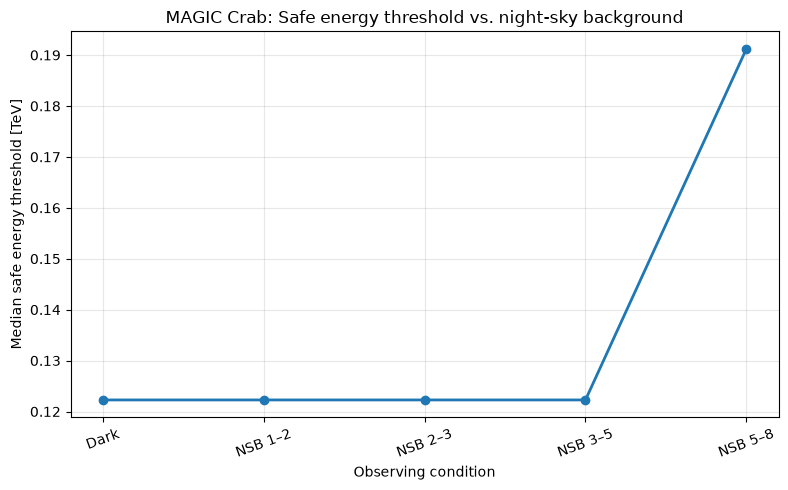

In [11]:
labels = [
    "Dark",
    "NSB 1–2",
    "NSB 2–3",
    "NSB 3–5",
    "NSB 5–8",
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    labels,
    comparison_df["safe_energy_min_TeV"],
    marker="o",
    linewidth=2,
)

ax.set_ylabel("Median safe energy threshold [TeV]")
ax.set_xlabel("Observing condition")
ax.set_title(
    "MAGIC Crab: Safe energy threshold vs. night-sky background"
)
ax.grid(alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    RESULTS_DL3_FIGURES
    / "safe_energy_threshold_vs_nsb.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation: sichere Energieschwelle

Gemessene Medianwerte:

- Dark: **0.122 TeV**
- NSB 1–2: **0.122 TeV**
- NSB 2–3: **0.122 TeV**
- NSB 3–5: **0.122 TeV**
- NSB 5–8: **0.191 TeV**

Erst bei der hellsten NSB-Gruppe steigt die sichere untere Energiegrenze deutlich an.

**Anschaulich:** Bei starkem Mondlicht sind schwächere Cherenkov-Signale schwerer zuverlässig vom optischen Nachthimmel zu trennen. Die Analyse verwirft deshalb den niedrigsten Energiebereich und beginnt erst bei höheren Energien.

Das ist genau der Zweck der `SafeMaskMaker`-Maske: Nur Energiebereiche mit ausreichend verlässlicher Instrumentantwort werden in die Statistik aufgenommen.

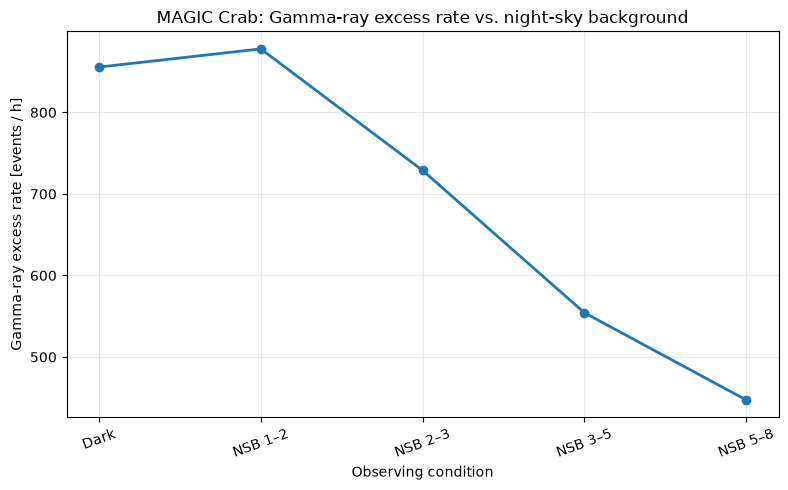

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    labels,
    comparison_df["excess_rate_per_h"],
    marker="o",
    linewidth=2,
)

ax.set_ylabel("Gamma-ray excess rate [events / h]")
ax.set_xlabel("Observing condition")
ax.set_title(
    "MAGIC Crab: Gamma-ray excess rate vs. night-sky background"
)
ax.grid(alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    RESULTS_DL3_FIGURES
    / "excess_rate_vs_nsb.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation: Excess-Rate bei zunehmendem NSB

Aus der gestackten Analyse:

| Bedingung | Runs | Livetime | Excess-Rate |
|---|---:|---:|---:|
| Dark | 98 | 28.65 h | **855.6 / h** |
| NSB 1–2 | 76 | 19.71 h | **877.9 / h** |
| NSB 2–3 | 3 | 0.89 h | **728.9 / h** |
| NSB 3–5 | 11 | 3.26 h | **554.2 / h** |
| NSB 5–8 | 10 | 2.95 h | **447.3 / h** |

Bei starkem NSB fällt die beobachtete Excess-Rate deutlich. Zusammen mit der höheren sicheren Energieschwelle ist das **konsistent mit einer schwierigeren Gamma-Analyse bei hellem Nachthimmel**.

Zwei wichtige Einschränkungen:

1. Der Verlauf ist bei kleinen NSB-Werten nicht monoton – `NSB 1–2` liegt sogar leicht über Dark.
2. `NSB 2–3` enthält nur **3 Runs**.

Die Gruppen unterscheiden sich außerdem nicht ausschließlich im Mondlicht, sondern können auch andere Beobachtungsbedingungen haben. Die Grafik ist daher **keine isolierte kausale Sensitivitätsmessung**, sondern ein Vergleich realer Beobachtungsgruppen.

# Analyse B – Einfluss des Camera Offsets

## 9. Was bedeutet Camera Offset?

Der **Camera Offset** ist der Winkelabstand zwischen der Quellposition und dem Zentrum des Kamerafelds bzw. der Pointing-Richtung.

Bei großen Offsets liegt die Quelle weiter am Rand der Kamera. Dort kann sich die Instrumentantwort verschlechtern, zum Beispiel durch geringere effektive Akzeptanz oder schlechtere Rekonstruktionsbedingungen.

Für diese Fragestellung verwenden wir ausschließlich `dark/multi_offset`. Dadurch vergleichen wir gezielt Beobachtungen bei verschiedenen Offsets und mischen sie nicht mit dem überlappenden `single_offset`-Sample.

In [13]:
multi_offset_files = files_by_group["dark_multi_offset"]

multi_summaries = []
multi_datasets = []
multi_failures = []

for file_path in multi_offset_files:
    n_off = get_n_off_regions(file_path)
    offset = file_path.parent.name

    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            dataset, summary, _ = process_magic_run(
                file_path,
                n_off_regions=n_off,
            )

        summary["offset"] = offset
        summary["n_off_regions"] = n_off
        summary["filename"] = file_path.name

        multi_summaries.append(summary)
        multi_datasets.append(dataset)

    except Exception as exc:
        multi_failures.append(
            {
                "file": file_path.name,
                "offset": offset,
                "n_off_regions": n_off,
                "error_type": type(exc).__name__,
                "error": str(exc),
            }
        )

multi_summary_df = pd.DataFrame(multi_summaries)

print("Successful:", len(multi_summaries))
print("Failed:    ", len(multi_failures))

if multi_failures:
    display(pd.DataFrame(multi_failures))

Successful: 71
Failed:     0


In [14]:
# Group and stack the processed datasets by camera offset.
multi_datasets_by_offset = defaultdict(list)

for summary, dataset in zip(
    multi_summaries,
    multi_datasets,
):
    multi_datasets_by_offset[
        summary["offset"]
    ].append(dataset)

offset_results = []

for offset, datasets in sorted(
    multi_datasets_by_offset.items()
):
    stacked = Datasets(datasets).stack_reduce()
    info = stacked.info_dict()

    livetime_h = float(
        info["livetime"].to_value("h")
    )

    offset_results.append(
        {
            "offset": offset,
            "offset_deg": float(
                offset.replace("offset_", "")
            ),
            "n_runs": len(datasets),
            "livetime_h": livetime_h,
            "excess": float(info["excess"]),
            "significance": float(info["sqrt_ts"]),
            "excess_rate_per_h":
                float(info["excess"]) / livetime_h,
        }
    )

offset_comparison_df = (
    pd.DataFrame(offset_results)
    .sort_values("offset_deg")
    .reset_index(drop=True)
)

offset_comparison_df.to_csv(
    RESULTS_DL3_TABLES / "camera_offset_comparison.csv",
    index=False,
)

display(
    offset_comparison_df[
        [
            "offset_deg",
            "n_runs",
            "livetime_h",
            "excess_rate_per_h",
        ]
    ].round(3)
)

 offset_deg  n_runs  livetime_h  excess_rate_per_h
       0.20       9       2.330            848.599
       0.35       3       0.884           1049.789
       0.40      26       7.943            903.507
       0.70       2       0.652            722.410
       1.00      15       4.446            462.338
       1.40      16       4.901            251.464

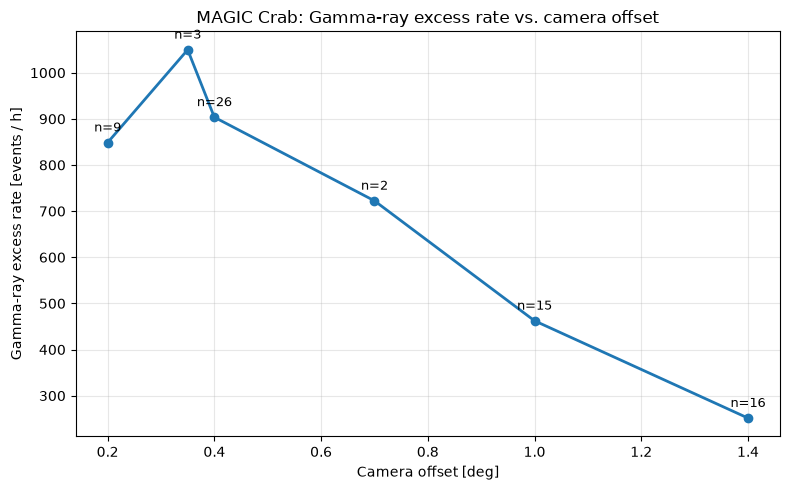

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    offset_comparison_df["offset_deg"],
    offset_comparison_df["excess_rate_per_h"],
    marker="o",
    linewidth=2,
)

# The number of runs is shown because some offset groups are small.
for _, row in offset_comparison_df.iterrows():
    ax.annotate(
        f"n={int(row['n_runs'])}",
        (
            row["offset_deg"],
            row["excess_rate_per_h"],
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xlabel("Camera offset [deg]")
ax.set_ylabel("Gamma-ray excess rate [events / h]")
ax.set_title(
    "MAGIC Crab: Gamma-ray excess rate vs. camera offset"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    RESULTS_DL3_FIGURES
    / "excess_rate_vs_camera_offset.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Interpretation: Camera Offset

Gemessene Excess-Raten:

| Offset | Runs | Livetime | Excess-Rate |
|---:|---:|---:|---:|
| 0.20° | 9 | 2.33 h | **848.6 / h** |
| 0.35° | 3 | 0.88 h | **1049.8 / h** |
| 0.40° | 26 | 7.94 h | **903.5 / h** |
| 0.70° | 2 | 0.65 h | **722.4 / h** |
| 1.00° | 15 | 4.45 h | **462.3 / h** |
| 1.40° | 16 | 4.90 h | **251.5 / h** |

Besonders ab etwa **0.4°** wird der Trend deutlich: Die Excess-Rate sinkt mit größerem Abstand vom Kamerazentrum. Von 0.40° bis 1.40° fällt sie von ungefähr **904 auf 251 Ereignisse pro Stunde**.

Das ist **konsistent mit einer schwächeren Off-Axis-Antwort** des Instruments.

Auch hier gilt: Das ist keine perfekte kontrollierte Sensitivitätskurve. Insbesondere die Gruppen bei 0.35° und 0.70° enthalten nur sehr wenige Runs. Deshalb werden die Messpunkte mit `n=...` direkt in der Grafik gekennzeichnet.

## 10. Gesamt-Nachweis im Multi-Offset-Sample

Zum Abschluss stacken wir alle 71 Multi-Offset-Runs. Dieser Wert dient nicht zum Vergleich einzelner Offsets, sondern zeigt, wie stark die Crab-Quelle im gesamten Dark-Multi-Offset-Sample nachgewiesen wird.

In [16]:
multi_stacked = Datasets(multi_datasets).stack_reduce()
multi_info = multi_stacked.info_dict()

multi_total = {
    "Runs": len(multi_datasets),
    "Livetime [h]": float(
        multi_info["livetime"].to_value("h")
    ),
    "ON": int(multi_info["counts"]),
    "OFF": int(multi_info["counts_off"]),
    "Background": float(multi_info["background"]),
    "Excess": float(multi_info["excess"]),
    "Significance [sigma]": float(
        multi_info["sqrt_ts"]
    ),
}

for key, value in multi_total.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.2f}")
    else:
        print(f"{key:20s}: {value}")

Runs                : 71
Livetime [h]        : 21.16
ON                  : 17826
OFF                 : 10833
Background          : 3985.17
Excess              : 13840.83
Significance [sigma]: 124.91


### Gesamt-Ergebnis

Die 71 Multi-Offset-Runs entsprechen etwa **21.16 h** Beobachtungszeit.

Die gestackte Analyse liefert:

- ON: **17,826**
- geschätzter Background: **3,985**
- Excess: **13,841**
- Signifikanz: **124.9 σ**

Damit ist der Crab-Nebel im kombinierten Sample extrem deutlich nachgewiesen.

Die große Signifikanz ist hier vor allem ein Nachweis dafür, dass die gesamte ON/OFF-Pipeline auf den realen MAGIC-Daten ein starkes Quellensignal extrahiert. Sie sollte nicht mit einer ML-Klassifikationsmetrik wie ROC-AUC oder Accuracy verwechselt werden.

# 11. Verbindung zum Machine-Learning-Teil

| UCI / Simulation | MAGIC DL3 / Realität |
|---|---|
| Monte-Carlo-Ereignisse | reale Teleskopbeobachtungen |
| Gamma-/Hadron-Ground-Truth pro Event | keine Ereignis-Ground-Truth |
| 10 Hillas-Bildparameter | rekonstruierte Richtung, Energie, Zeit + IRFs |
| supervised classification | statistische ON/OFF-Signalextraktion |
| TPR / FPR direkt messbar | Background und Excess statistisch geschätzt |
| Ziel: Gamma von Hadron unterscheiden | Ziel: Gammaquelle trotz Rest-Untergrund nachweisen |

Die gemeinsame fachliche Klammer ist **Background-Unterdrückung**:

- Im ML-Teil soll der Klassifikator möglichst viele Gamma-Ereignisse erkennen, während nur wenige Hadronen fälschlich akzeptiert werden.
- Im realen DL3-Teil ist nach der Ereignisselektion immer noch Untergrund vorhanden. Die Quelle wird deshalb über ON/OFF-Statistik nachgewiesen.

### Wichtigste Limitation

Das UCI-Modell kann **nicht direkt auf die DL3-Ereignisse angewendet werden**, weil die benötigten UCI-Bildparameter in DL3 nicht vorhanden sind. Der DL3-Teil ist daher kein klassisches Hold-out-Testset für das ML-Modell, sondern ein **Realitätscheck auf einer anderen Datenebene**.

# 12. Fazit

Der Real-Data-Teil liefert drei zentrale Erkenntnisse:

1. **Realer Quellennachweis:** Schon ein einzelner Run zeigt einen deutlichen Crab-Excess; im 71-Run-Multi-Offset-Stack erreicht der Nachweis etwa **124.9 σ**.
2. **Night-Sky Background:** Bei starkem NSB steigt die sichere Energiegrenze auf etwa **0.19 TeV** und die beobachtete Excess-Rate nimmt deutlich ab.
3. **Camera Offset:** Bei großen Offsets sinkt die Excess-Rate stark; die Quelle wird am Rand des Kamerafelds weniger effizient nachgewiesen.

Gleichzeitig zeigt der DL3-Teil eine wichtige Data-Science-Lektion:

> **Ein gut funktionierendes Modell auf Simulation ist nicht automatisch ein direkt validierbares Modell auf realen Daten. Datenebene, Feature-Raum, Ground Truth und Messbedingungen müssen zusammenpassen.**

### Methodische Grenzen

- Excess-Ereignisse sind **statistisch** geschätzte Quellereignisse, keine Event-für-Event-Labels.
- Die NSB- und Offset-Gruppen bilden reale Beobachtungen ab und sind keine vollständig kontrollierten Experimente.
- Einige Gruppen enthalten nur wenige Runs.
- `Excess / h` ist eine anschauliche Vergleichsgröße, aber **keine vollständige instrumentelle Sensitivität**.
- Für eine weiterführende astronomische Analyse wären beispielsweise Spektral-Fits und ein detaillierter Vergleich der IRFs sinnvoll.

Für das Portfolio reicht dieser Umfang bewusst aus: Er zeigt eine reproduzierbare reale Analyse, macht die Grenzen des simulierten ML-Benchmarks sichtbar und verbindet beide Projektteile über das gemeinsame Signal-vs.-Background-Problem.